In [1]:
import pandas as pd

# load data
train_data = pd.read_csv('train.csv')
test_data = pd.read_csv('test.csv')

# print data
print("Train Data:")
print(train_data.head())


print("\nTest Data:")
print(test_data.head())

print(train_data.shape)
print(test_data.shape)

Train Data:
   id  MonsoonIntensity  TopographyDrainage  RiverManagement  Deforestation  \
0   0                 5                   8                5              8   
1   1                 6                   7                4              4   
2   2                 6                   5                6              7   
3   3                 3                   4                6              5   
4   4                 5                   3                2              6   

   Urbanization  ClimateChange  DamsQuality  Siltation  AgriculturalPractices  \
0             6              4            4          3                      3   
1             8              8            3          5                      4   
2             3              7            1          5                      4   
3             4              8            4          7                      6   
4             4              4            3          3                      3   

   ...  DrainageSystems  C

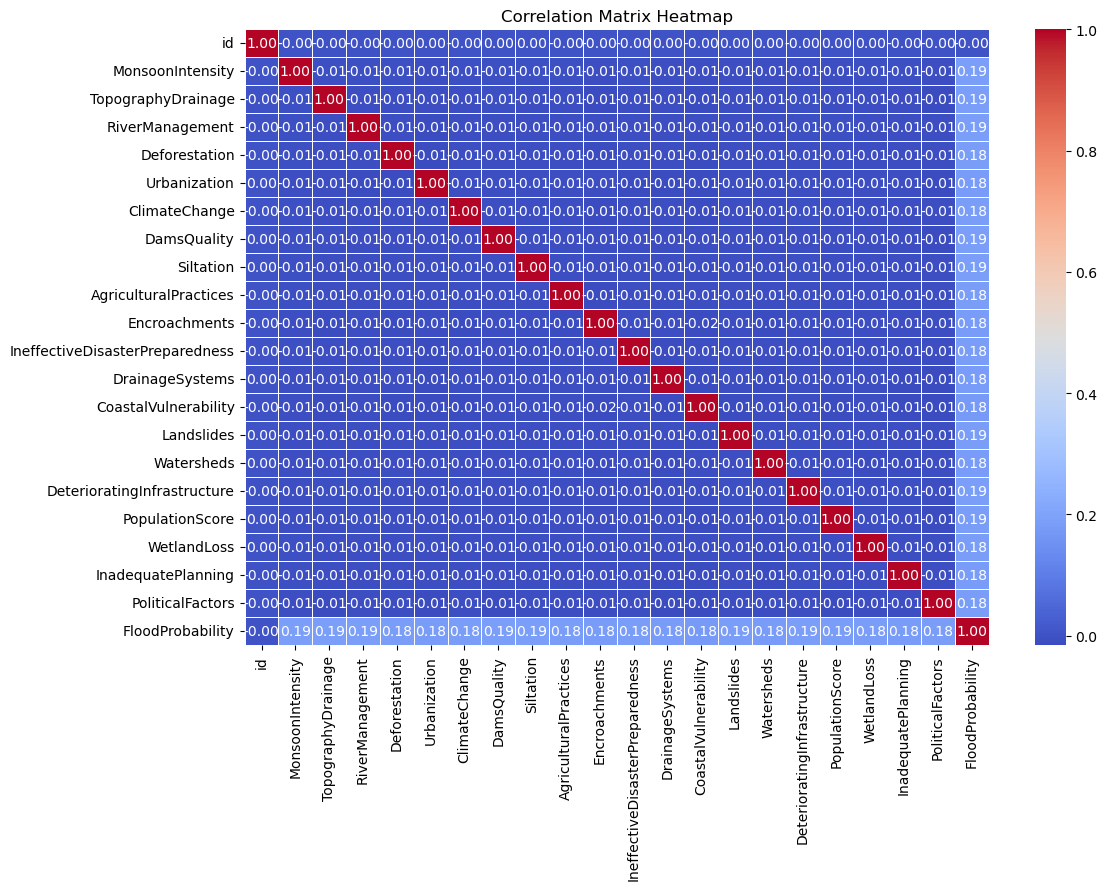

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

# plot matrix
correlation_matrix = train_data.corr()

# plot picture
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix Heatmap")
plt.show()

In [3]:
correlation_matrix["FloodProbability"].sort_values(ascending=False)

FloodProbability                   1.000000
DeterioratingInfrastructure        0.190007
MonsoonIntensity                   0.189098
DamsQuality                        0.187996
TopographyDrainage                 0.187635
RiverManagement                    0.187131
Siltation                          0.186789
PopulationScore                    0.185890
Landslides                         0.185346
ClimateChange                      0.184761
Deforestation                      0.184001
WetlandLoss                        0.183396
AgriculturalPractices              0.183366
IneffectiveDisasterPreparedness    0.183109
PoliticalFactors                   0.182417
Watersheds                         0.181907
InadequatePlanning                 0.180968
Urbanization                       0.180861
DrainageSystems                    0.179305
Encroachments                      0.178841
CoastalVulnerability               0.177774
id                                -0.000184
Name: FloodProbability, dtype: f

In [4]:
# check null
print(train_data.isnull().sum())

# fill null with mean
train_data.fillna(train_data.mean(), inplace=True)
test_data.fillna(test_data.mean(), inplace=True)

# check output
print(train_data.isnull().sum())

id                                 0
MonsoonIntensity                   0
TopographyDrainage                 0
RiverManagement                    0
Deforestation                      0
Urbanization                       0
ClimateChange                      0
DamsQuality                        0
Siltation                          0
AgriculturalPractices              0
Encroachments                      0
IneffectiveDisasterPreparedness    0
DrainageSystems                    0
CoastalVulnerability               0
Landslides                         0
Watersheds                         0
DeterioratingInfrastructure        0
PopulationScore                    0
WetlandLoss                        0
InadequatePlanning                 0
PoliticalFactors                   0
FloodProbability                   0
dtype: int64
id                                 0
MonsoonIntensity                   0
TopographyDrainage                 0
RiverManagement                    0
Deforestation            

In [5]:
X = train_data.drop(['FloodProbability', 'id'], axis=1)
y = train_data['FloodProbability']

In [6]:
from sklearn.model_selection import train_test_split

# split data
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

In [8]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly = poly.fit_transform(X_train_scaled)

In [9]:
from sklearn.linear_model import Ridge

model = Ridge(alpha=1.0)  
model.fit(X_train_poly, y_train)

Ridge()

In [10]:
from sklearn.metrics import mean_squared_error

X_val_scaled = scaler.transform(X_val)
X_val_poly = poly.transform(X_val_scaled)


y_val_pred = model.predict(X_val_poly)

mse = mean_squared_error(y_val, y_val_pred)
print(f'MSE: {mse}')

MSE: 0.00040180885527247423


In [11]:
test_data = test_data.drop(['id'], axis=1)

test_data_scaled = scaler.transform(test_data)
test_data_poly = poly.transform(test_data_scaled)

# predict
y_test_pred = model.predict(test_data_poly)

# submission
submission = pd.DataFrame({
    #'id': test_data['id'],
    'FloodProbability': y_test_pred
})

submission.to_csv('flood_predictions.csv', index=False)